In [25]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D 
from matplotlib import gridspec
import matplotlib.colors as colors
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib import cm
from matplotlib.patches import Patch

import os
import scanpy as sc

import seaborn as sns
import snapatac2 as snap

snap.__version__


'2.9.0'

## Load Data

In [2]:
entropy_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F'
Union_cell_subdir = os.path.join(entropy_dir, '_cell_calling_comparison')
Union_cell_info_file = os.path.join(Union_cell_subdir, 'Union_cell_3set_with_stringent_calling.tsv')
union_cell_info = pd.read_csv(Union_cell_info_file, sep='\t', index_col=0)
union_cell_info['index'] = union_cell_info.index.map(lambda x: x + '-1')

union_cell_info.head(2)

,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,rna_barcodes,rna_pass_CR,Entropy,leiden_RNA_scVI,DNA_debris,_3set_identified_by_atac,P_closed_state,stringent_cell_calling,index
atac_bc,,,,,,,,,,,,,,,
AAACAAGCAAGTTAGT,2412,True,True,True,both,both,GGCTAGTGTGTTAGCA,True,0.218328,3,NO,common,0.965116,True,AAACAAGCAAGTTAGT-1
AAACAAGCATTTCTTC,9030,True,True,True,both,both,GGCTAGTGTACGTTTC,True,0.074451,0,NO,common,0.990949,True,AAACAAGCATTTCTTC-1


In [3]:
nucleosome_info_file = os.path.join(Union_cell_subdir, 'nucleosome_signal_by_cell.csv')
nucleosome_info = pd.read_csv(nucleosome_info_file, index_col=0)
nucleosome_info['index'] = nucleosome_info.index.map(lambda x: x + '-1')
nucleosome_info.head(2)

,nucleosome_signal,index
atac_bc,,
AAACAAGCAAGTTAGT,-1.552972,AAACAAGCAAGTTAGT-1
AAACAAGCATTTCTTC,-1.926050,AAACAAGCATTTCTTC-1


In [4]:
frip_score_file = os.path.join(Union_cell_subdir, 'frip_cells_info.tsv')
frip_score_info = pd.read_csv(frip_score_file, sep='\t', index_col=0)
frip_score_info['index'] = frip_score_info.index.map(lambda x: x + '-1')
frip_score_info.head(2)

,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,rna_barcodes,rna_pass_CR,Entropy,leiden_RNA_scVI,DNA_debris,Nfrag_in_raw_peaks,Nfrag_in_entropy_peaks,Nfrag_in_tss_peaks,Nfrag_in_frip_peaks,FRIP_raw_peaks,FRIP_entropy_peaks,FRIP_tss_peaks,FRIP_frip_peaks,index
atac_bc,,,,,,,,,,,,,,,,,,,,
AAACAAGCAAGTTAGT,2412,True,True,True,both,both,GGCTAGTGTGTTAGCA,True,0.218328,3,NO,1729,1919,1933,1785,71.683250,79.560531,80.140962,74.004975,AAACAAGCAAGTTAGT-1
AAACAAGCATTTCTTC,9030,True,True,True,both,both,GGCTAGTGTACGTTTC,True,0.074451,0,NO,1538,1847,1877,1635,17.032115,20.454042,20.786268,18.106312,AAACAAGCATTTCTTC-1


In [5]:
amulet_doublet_atac_file = os.path.join(Union_cell_subdir, 'AMULET_output/MultipletBarcodes_01.txt')
doublet_atac_barcodes = pd.read_csv(amulet_doublet_atac_file, header=None)
doublet_atac_barcodes.columns = ['barcodes']
doublet_atac_barcodes['atac_bc'] = doublet_atac_barcodes['barcodes'].str.split('-').str[0]
doublet_atac_barcodes.head(2)



,barcodes,atac_bc
0,AAAGCCTAGGATTATG-1,AAAGCCTAGGATTATG
1,AAAGGCGCACTAATCC-1,AAAGGCGCACTAATCC


In [6]:
os.path.join(Union_cell_subdir, '_SNAPataC_analysis', 'binnedGenome_all_unioncells.h5ad')

'/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F/_cell_calling_comparison/_SNAPataC_analysis/binnedGenome_all_unioncells.h5ad'

In [7]:
data = sc.read_h5ad(os.path.join(Union_cell_subdir, '_SNAPataC_analysis', 'binnedGenome_all_unioncells.h5ad'))

In [8]:
data.obs[(data.obs['amulet_doublet_atac'] == True) | (data.obs['DNA_debris'] == 'YES') ].groupby(['_3set_identified_by_atac']).size()

/tmp/ipykernel_3013414/2208233013.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.obs[(data.obs['amulet_doublet_atac'] == True) | (data.obs['DNA_debris'] == 'YES') ].groupby(['_3set_identified_by_atac']).size()


_3set_identified_by_atac
CR unique           22
CR+TSS, not SADE     0
SADE unique          0
SADE+CR, not TSS    11
SADE+TSS, not CR     0
TSS unique           0
common              65
dtype: int64

In [9]:
data.obs[(data.obs['amulet_doublet_atac'] == True) | (data.obs['DNA_debris'] == 'YES') ].groupby(['leiden_RNA_scVI']).size()

/tmp/ipykernel_3013414/3826379241.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.obs[(data.obs['amulet_doublet_atac'] == True) | (data.obs['DNA_debris'] == 'YES') ].groupby(['leiden_RNA_scVI']).size()


leiden_RNA_scVI
0              11
1              15
2              15
3               6
4               0
5               3
6               5
7               3
8              20
9               2
10              0
11             18
no_rna_info     0
dtype: int64

In [10]:
data_filter = sc.read_h5ad(os.path.join(Union_cell_subdir, '_SNAPataC_analysis', 'binnedGenome_unioncells_filtered.h5ad'))

# filtered_leiden_file = os.path.join(Union_cell_subdir, '_SNAPataC_analysis', 'binnedGenome_unioncells_filtered_obs.csv')
# data_filter.obs[[ 'leiden', 'filtered_leiden']].to_csv(
#     filtered_leiden_file)

# Vis

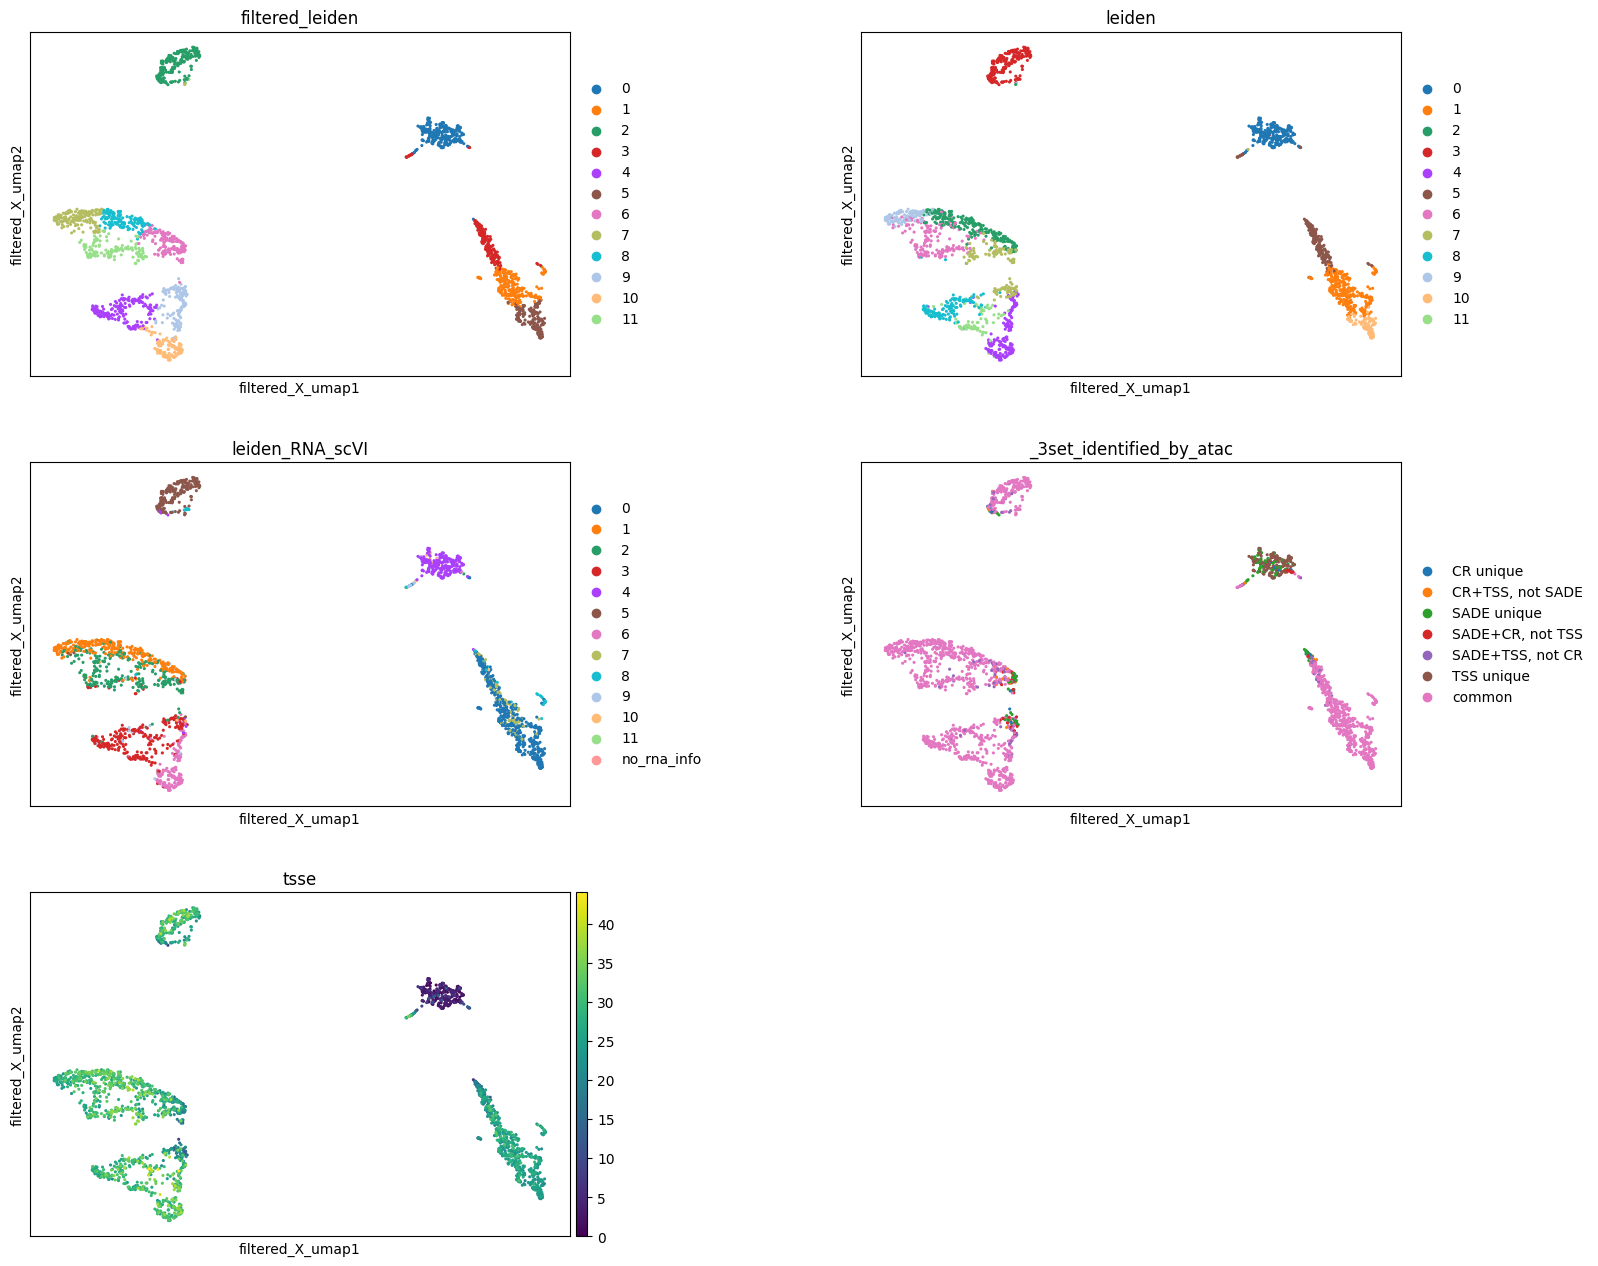

In [13]:
sc.pl.embedding(data_filter, basis='filtered_X_umap', color=['filtered_leiden', 'leiden', 'leiden_RNA_scVI', '_3set_identified_by_atac', 'tsse'], s=20, ncols=2, wspace=0.4)

# Peak calling

In [11]:
snap.tl.macs3(data_filter, groupby='filtered_leiden')

2026-04-20 19:04:04 - INFO - Exporting fragments...


2026-04-20 19:04:07 - INFO - Calling peaks...
100%|██████████| 12/12 [00:40<00:00,  3.38s/it]


In [12]:
for a in data_filter.uns['macs3'].keys():
    print(a, data_filter.uns['macs3'][a].shape)

2 (44058, 10)
11 (34235, 10)
4 (44342, 10)
5 (71912, 10)
3 (37615, 10)
1 (65729, 10)
0 (2928, 10)
9 (21834, 10)
6 (18629, 10)
7 (45892, 10)
8 (31009, 10)
10 (42705, 10)


In [13]:
peaks = snap.tl.merge_peaks(data_filter.uns['macs3'], snap.genome.hg38)
peaks.head(2)

Peaks,3,4,7,10,0,9,6,2,1,8,5,11
str,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool
"""chr1:9932-10433""",false,false,true,true,false,false,false,false,true,false,false,false
"""chr1:180622-181123""",false,true,false,true,false,false,false,false,true,true,true,false


In [15]:
peaks.shape

(119884, 13)

In [16]:
peak_mat = snap.pp.make_peak_matrix(data_filter, use_rep=peaks['Peaks'])
peak_mat

AnnData object with n_obs × n_vars = 2286 × 119884
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'rna_pass_CR', 'atac_pass_CR', 'atac_pass_entropy', 'atac_pass_archr_TSS', '_2set_identified_by_atac_SC', '_2set_identified_by_atac_ST', '_3set_identified_by_atac', 'DNA_debris', 'amulet_doublet_atac', 'leiden_RNA_scVI', 'total_fragments', 'FRIP_raw_peaks', 'FRIP_entropy_peaks', 'FRIP_tss_peaks', 'FRIP_frip_peaks', 'nucleosome_signal', 'tsse', 'leiden', 'leiden_scanpy', 'filtered_leiden'

In [ ]:
marker_peaks = snap.tl.marker_regions(peak_mat, groupby='filtered_leiden', pvalue=0.01)

In [83]:
for a in marker_peaks.keys():
    print(a, len(marker_peaks[a]))

2 3830
5 7139
1 1342
4 5945
6 6710
0 13485
7 1575
9 5928
3 2081
11 1174
8 1250
10 854


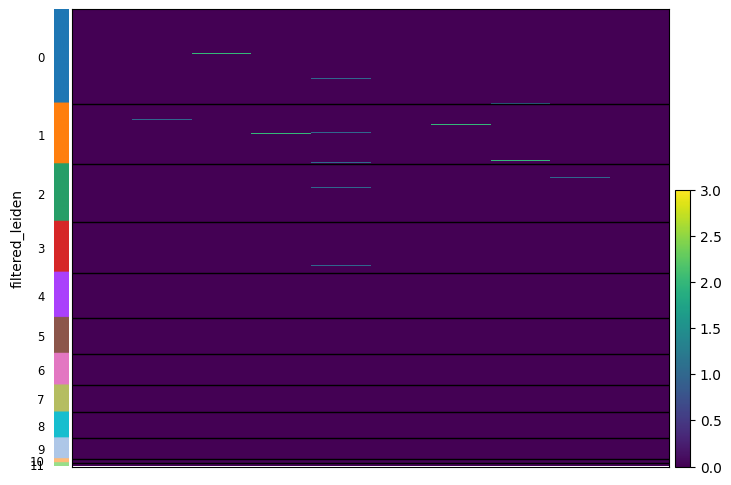

In [78]:
sc.pl.heatmap(peak_mat, marker_peaks['1'][:10], groupby='filtered_leiden', show_gene_labels=False, cmap='viridis')

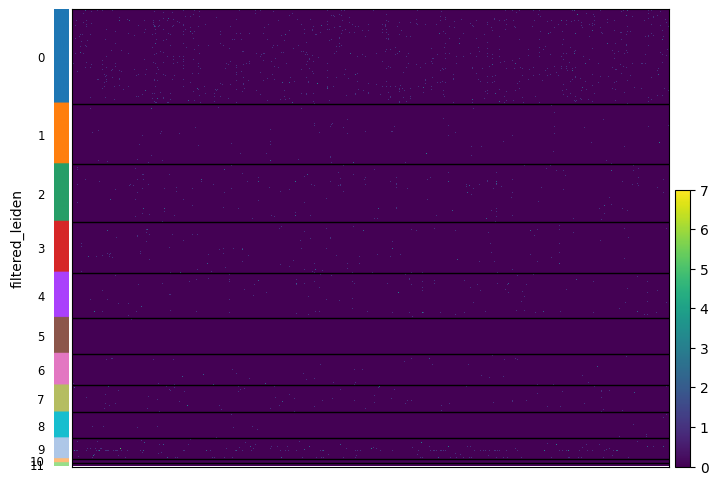

In [81]:
sc.pl.heatmap(peak_mat, marker_peaks['9'], groupby='filtered_leiden', show_gene_labels=False, cmap='viridis')

In [82]:
motifs = snap.tl.motif_enrichment(
    motifs=snap.datasets.cis_bp(unique=True),
    regions=marker_peaks,
    genome_fasta=snap.genome.hg38,
)

2026-04-17 18:05:13 - INFO - Fetching 51313 sequences ...
100%|████████████████████████████████████████| 845M/845M [00:00<00:00, 954GB/s]
Decompressing '/home/syyang/.cache/snapatac2/gencode_v41_GRCh38.fa.gz' to '/home/syyang/.cache/snapatac2/gencode_v41_GRCh38.fa.gz.decomp' using method 'gzip'.
2026-04-17 18:08:57 - INFO - Computing enrichment ...
100%|██████████| 1165/1165 [01:56<00:00,  9.98it/s]


In [97]:

def motif_enrichment(
    enrichment, 
    min_log_fc: float = 1,
    max_fdr: float = 0.01):
    fc = np.vstack([df['log2(fold change)'] for df in enrichment.values()])
    filter1 = np.apply_along_axis(lambda x: np.any(np.abs(x) >= min_log_fc), 0, fc)
    
    fdr = np.vstack([df['adjusted p-value'] for df in enrichment.values()])
    filter2 = np.apply_along_axis(lambda x: np.any(x <= max_fdr), 0, fdr)

    passed = np.logical_and(filter1, filter2)
    
    sign = np.sign(fc[:, passed])
    pvals = np.vstack([df['p-value'].to_numpy()[passed] for df in enrichment.values()])
    minval = np.min(pvals[np.nonzero(pvals)])
    pvals = np.clip(pvals, minval, None)
    pvals = sign * np.log(-np.log10(pvals))

    df = pd.DataFrame(
        pvals.T,
        columns=list(enrichment.keys()),
        index=next(iter(enrichment.values()))['id'].to_numpy()[passed],
    )
      
    return df

In [105]:
motifs_df = motif_enrichment(motifs)
motifs_df.shape

(185, 12)

Text(0.5, 1.0, 'Motif Enrichment Heatmap')

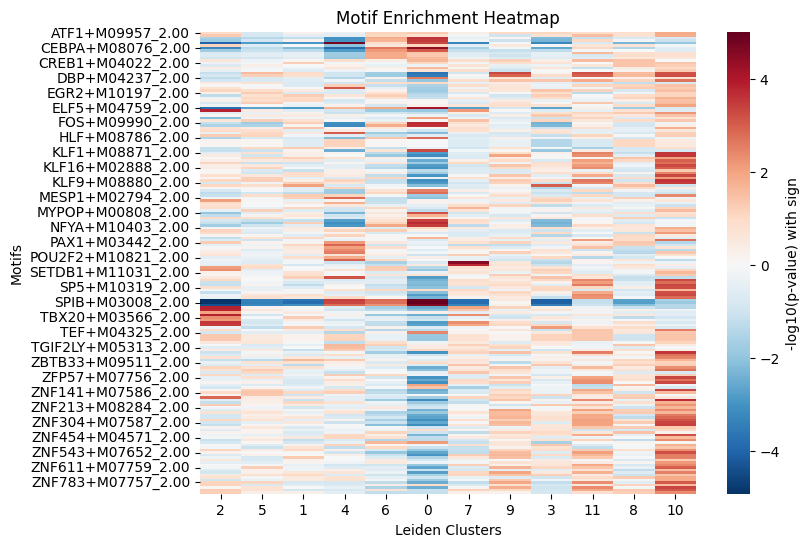

In [103]:
# heatmap plot of motif enrichment results
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(motifs_df, cmap='RdBu_r', center=0, cbar_kws={'label': '-log10(p-value) with sign'}, ax=ax)
ax.set_xlabel('Leiden Clusters')
ax.set_ylabel('Motifs')
ax.set_title('Motif Enrichment Heatmap')

In [91]:
motifs['5']

id,name,family,log2(fold change),p-value,adjusted p-value
str,str,null,f64,f64,f64
"""AC023509.3+M02872_2.00""","""AC023509.3""",null,-0.935829,0.02352,0.168105
"""AC138696.1+M04597_2.00""","""AC138696.1""",null,-0.25728,0.111988,0.354528
"""AHR+M09817_2.00""","""AHR""",null,0.052973,0.485274,0.517239
"""AIRE+M09375_2.00""","""AIRE""",null,-0.043911,0.379455,0.505337
"""ALX1+M05327_2.00""","""ALX1""",null,-0.051323,0.353706,0.503815
…,…,…,…,…,…
"""ZSCAN4+M02919_2.00""","""ZSCAN4""",null,-0.117342,0.175322,0.410751
"""ZSCAN5+M04460_2.00""","""ZSCAN5""",null,-0.01954,0.442195,0.508156
"""ZSCAN5C+M08390_2.00""","""ZSCAN5C""",null,0.193454,0.044442,0.23074


# Save results

In [83]:
gene_matrix

AnnData object with n_obs × n_vars = 2286 × 42164
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'rna_pass_CR', 'atac_pass_CR', 'atac_pass_entropy', 'atac_pass_archr_TSS', '_2set_identified_by_atac_SC', '_2set_identified_by_atac_ST', '_3set_identified_by_atac', 'DNA_debris', 'amulet_doublet_atac', 'leiden_RNA_scVI', 'total_fragments', 'FRIP_raw_peaks', 'FRIP_entropy_peaks', 'FRIP_tss_peaks', 'FRIP_frip_peaks', 'nucleosome_signal', 'tsse', 'leiden', 'leiden_scanpy', 'filtered_leiden', 'total_activity_score'
    var: 'n_cells'
    uns: 'log1p', 'leiden_colors', 'filtered_leiden_colors', 'leiden_RNA_scVI_colors'
    obsm: 'X_umap', 'filtered_X_umap'

In [84]:
gene_matrix.layers

Layers with keys: 

In [85]:
cluster_average_df = pd.DataFrame(index=gene_matrix.var_names)

for c in gene_matrix.obs['filtered_leiden'].unique():
    a = gene_matrix[gene_matrix.obs['filtered_leiden'] == c, :].X.mean(axis=0)
    cluster_average_df[c] = np.asarray(a).flatten()


gene_activity_file = os.path.join(Union_cell_subdir, '_SNAPataC_analysis', 'filtered_leiden_cluster_average_gene_activity.csv')
cluster_average_df.to_csv(gene_activity_file)

cluster_average_df.head()

,9,0,2,3,5,4,11,1,8,6,7,10
DDX11L1,0.006192,-0.000265,-0.000090,0.005396,0.009194,0.004222,0.004665,0.008400,0.005341,0.003455,0.006073,0.011597
ENSG00000238009,0.001562,0.000259,-0.000336,0.002771,0.005044,0.000926,0.000593,0.004244,0.001162,0.000742,0.001480,0.003264
DDX11L17,0.013704,0.004166,0.009312,0.006436,0.008323,0.021762,0.016531,0.007969,0.011664,0.009858,0.011817,0.018674
WASH9P,0.004777,0.002714,0.001978,0.005787,0.009463,0.009853,0.007026,0.008218,0.004898,0.003735,0.006327,0.006227
ENSG00000228463,0.002078,0.000530,0.003067,0.015467,0.026384,0.002788,0.002331,0.022870,0.002649,0.002049,0.002864,0.002787


In [86]:
gene_matrix.write_h5ad(os.path.join(Union_cell_subdir, '_SNAPataC_analysis', 'gene_activity.h5ad'))

## Check AMULET doublet 

In [121]:
distinguishable_colors = ['#1f77b4',
 '#aec7e8',
 '#ff7f0e',
 '#ffbb78',
 '#2ca02c',
 '#98df8a',
 '#d62728',
 '#ff9896',
 '#9467bd',
 '#c5b0d5',
 '#8c564b',
 '#c49c94',
 '#e377c2',
 '#f7b6d2',
 '#7f7f7f',
 '#c7c7c7',
 '#bcbd22',
 '#dbdb8d',
 '#17becf',
 '#9edae5']

['#1f77b4',
 '#aec7e8',
 '#ff7f0e',
 '#ffbb78',
 '#2ca02c',
 '#98df8a',
 '#d62728',
 '#ff9896',
 '#9467bd',
 '#c5b0d5',
 '#8c564b',
 '#c49c94',
 '#e377c2',
 '#f7b6d2',
 '#7f7f7f',
 '#c7c7c7',
 '#bcbd22',
 '#dbdb8d',
 '#17becf',
 '#9edae5']